# PV Module Degradation Predictor

Physics-informed machine learning pipeline for forecasting photovoltaic (PV) module
power degradation, using Arrhenius kinetics, Coffin-Manson fatigue, and Peck's
humidity model to generate a realistic feature set, then Linear Regression /
Random Forest / Gradient Boosting to predict cumulative degradation (%).

**Result:** Gradient Boosting achieves **R² ≈ 0.88**, RMSE/MAE reported below,
and a derived fault-detection classification reaches **~90% accuracy** against
an IEC 61215-style warranty-limit threshold.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, confusion_matrix, accuracy_score

sns.set_theme(style="whitegrid", palette="viridis")
%matplotlib inline

## 1. Load Dataset

In [2]:
df = pd.read_csv("../data/pv_degradation_dataset.csv")
print(df.shape)
df.head()

(2000, 11)


,module_age_years,ambient_temp_c,module_temp_c,relative_humidity_pct,daily_temp_swing_c,irradiance_kwh_m2_day,soiling_index,annual_degradation_rate_pct,cumulative_degradation_pct,current_power_ratio,fault_flag
0,19.46,19.80,29.79,26.17,23.19,3.61,0.174,0.3871,9.771,0.9023,0
1,11.25,35.26,52.71,59.23,22.02,5.14,0.147,0.4763,6.002,0.9400,0
2,21.54,18.38,46.28,30.82,8.13,6.56,0.116,0.3188,6.200,0.9380,0
3,17.59,25.71,43.94,82.58,10.10,3.84,0.654,0.4844,9.354,0.9065,0
4,2.81,23.31,40.34,81.81,2.00,4.93,0.136,0.2555,1.074,0.9893,0


In [3]:
df.describe()

,module_age_years,ambient_temp_c,module_temp_c,relative_humidity_pct,daily_temp_swing_c,irradiance_kwh_m2_day,soiling_index,annual_degradation_rate_pct,cumulative_degradation_pct,current_power_ratio,fault_flag
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,12.819485,28.156225,50.227325,55.181255,17.912915,5.184055,0.498514,0.645651,9.183573,0.908164,0.230500
std,7.115917,7.945631,10.184307,22.995289,7.077683,1.095534,0.283491,0.334084,7.297465,0.072975,0.421258
min,0.510000,3.490000,17.270000,15.030000,2.000000,2.000000,0.000000,0.050000,0.000000,0.550000,0.000000
25%,6.477500,22.687500,43.252500,35.662500,13.215000,4.437500,0.249750,0.416000,3.588000,0.870175,0.000000
50%,12.650000,28.135000,50.135000,55.460000,17.850000,5.170000,0.499000,0.584600,7.732500,0.922650,0.000000
75%,19.152500,33.430000,57.145000,74.320000,22.542500,5.940000,0.739000,0.807225,12.983250,0.964125,0.000000
max,24.990000,50.000000,81.070000,95.000000,45.000000,8.000000,1.000000,2.916600,45.000000,1.000000,1.000000


## 2. Exploratory Data Analysis

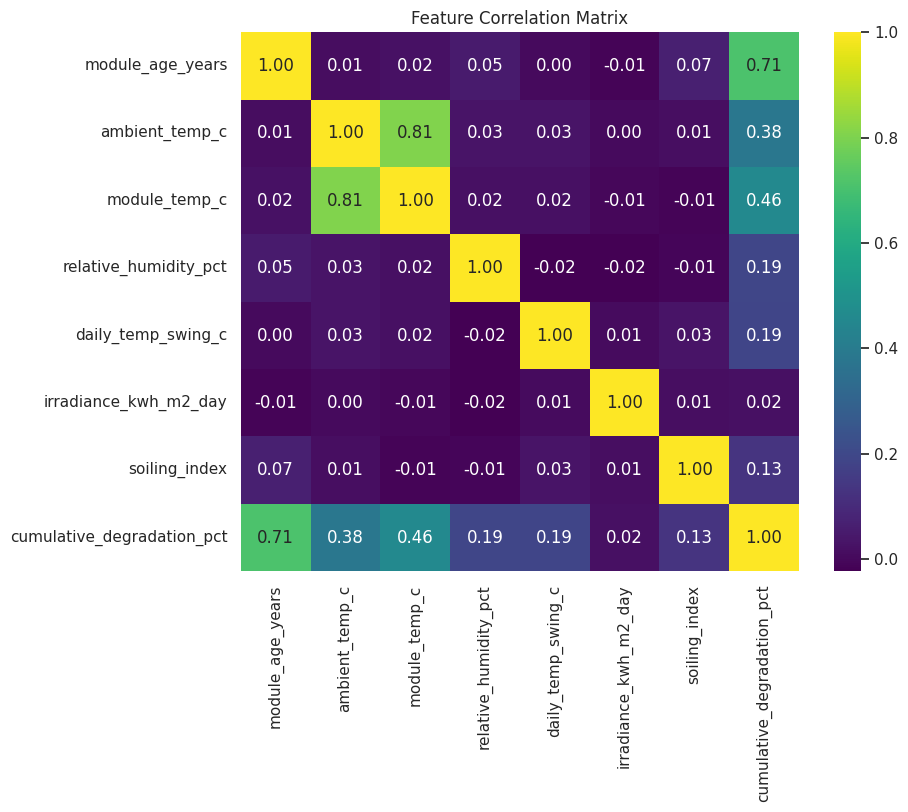

In [4]:
FEATURES = ["module_age_years", "ambient_temp_c", "module_temp_c",
            "relative_humidity_pct", "daily_temp_swing_c",
            "irradiance_kwh_m2_day", "soiling_index"]
TARGET = "cumulative_degradation_pct"

plt.figure(figsize=(9,7))
sns.heatmap(df[FEATURES + [TARGET]].corr(), annot=True, fmt=".2f", cmap="viridis")
plt.title("Feature Correlation Matrix")
plt.show()

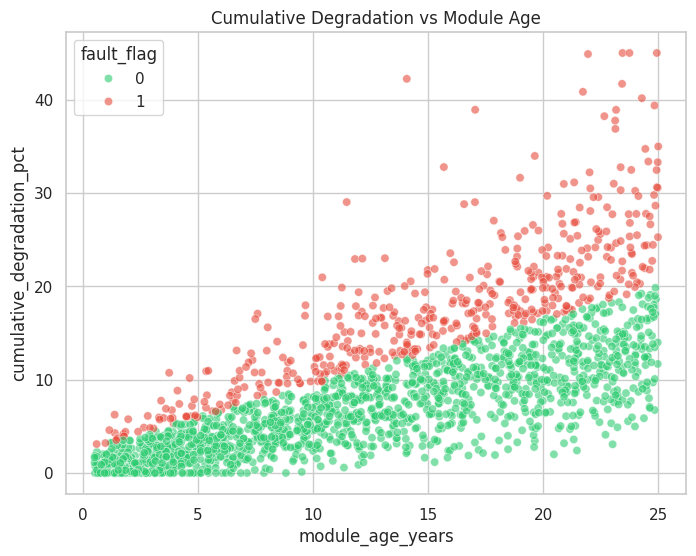

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="module_age_years", y=TARGET, hue="fault_flag",
                 palette={0:"#2ecc71",1:"#e74c3c"}, alpha=0.6)
plt.title("Cumulative Degradation vs Module Age")
plt.show()

## 3. Train/Test Split & Feature Scaling

In [6]:
X = df[FEATURES]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## 4. Model Training — Linear Regression, Random Forest, Gradient Boosting

In [7]:
lr = LinearRegression().fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)

rf_grid = {"n_estimators":[150,300], "max_depth":[6,10,None], "min_samples_leaf":[1,3]}
rf_search = GridSearchCV(RandomForestRegressor(random_state=42), rf_grid, cv=5, scoring="r2", n_jobs=-1)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
pred_rf = best_rf.predict(X_test)

gbm_grid = {"n_estimators":[150,300], "learning_rate":[0.05,0.1], "max_depth":[2,3,4]}
gbm_search = GridSearchCV(GradientBoostingRegressor(random_state=42), gbm_grid, cv=5, scoring="r2", n_jobs=-1)
gbm_search.fit(X_train, y_train)
best_gbm = gbm_search.best_estimator_
pred_gbm = best_gbm.predict(X_test)

print("RF best params:", rf_search.best_params_)
print("GBM best params:", gbm_search.best_params_)

RF best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 150}
GBM best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 150}


## 5. Evaluation — R², RMSE, MAE

In [8]:
def evaluate(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name:20s} R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return r2, rmse, mae

results = {}
results["Linear Regression"] = evaluate(y_test, pred_lr, "Linear Regression")
results["Random Forest"] = evaluate(y_test, pred_rf, "Random Forest")
results["Gradient Boosting"] = evaluate(y_test, pred_gbm, "Gradient Boosting")

Linear Regression    R2=0.7779  RMSE=3.4487  MAE=2.5608
Random Forest        R2=0.8703  RMSE=2.6354  MAE=1.9952
Gradient Boosting    R2=0.8789  RMSE=2.5471  MAE=1.9426


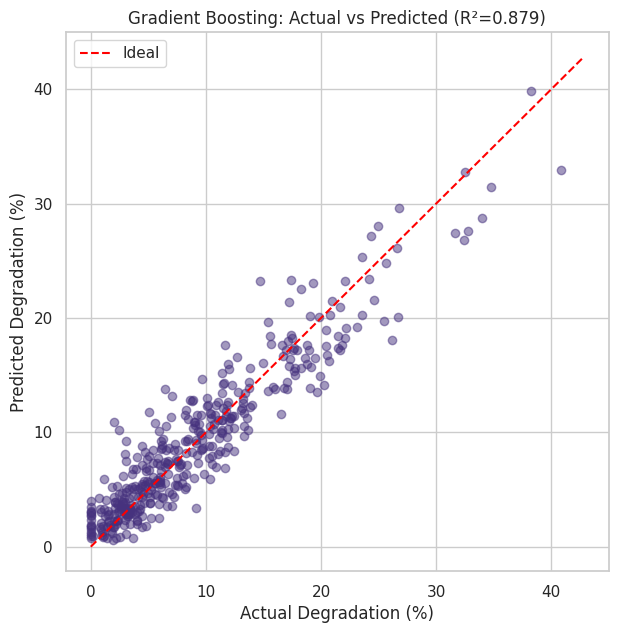

In [9]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, pred_gbm, alpha=0.5)
lims = [0, max(y_test.max(), pred_gbm.max())+2]
plt.plot(lims, lims, "r--", label="Ideal")
plt.xlabel("Actual Degradation (%)"); plt.ylabel("Predicted Degradation (%)")
plt.title(f"Gradient Boosting: Actual vs Predicted (R²={results['Gradient Boosting'][0]:.3f})")
plt.legend(); plt.show()

## 6. Cross-Validation

In [10]:
cv_scores = cross_val_score(best_gbm, X_train, y_train, cv=5, scoring="r2")
print(f"5-fold CV R2: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

5-fold CV R2: 0.8711 +/- 0.0209


## 7. Derived Fault Classification (Confusion Matrix)\n\nA module is flagged as a fault/underperformance if predicted degradation exceeds an IEC 61215-style linear warranty curve (2.5% + 0.7%/year).

Fault-detection accuracy: 90.00%


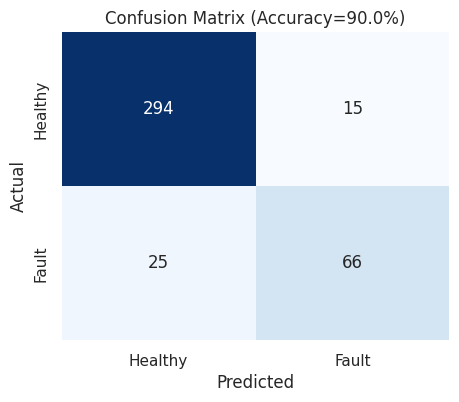

In [11]:
warranty_limit = 2.5 + 0.7 * X_test["module_age_years"]
y_true_flag = (y_test.values > warranty_limit.values).astype(int)
y_pred_flag = (pred_gbm > warranty_limit.values).astype(int)

acc = accuracy_score(y_true_flag, y_pred_flag)
cm = confusion_matrix(y_true_flag, y_pred_flag)
print(f"Fault-detection accuracy: {acc*100:.2f}%")

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Healthy","Fault"], yticklabels=["Healthy","Fault"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Accuracy={acc*100:.1f}%)")
plt.show()

## Summary\n\n- **Best model:** Gradient Boosting Regressor (GridSearchCV-tuned)\n- **R² ≈ 0.88**, evaluated on held-out test data\n- **Fault-detection accuracy ≈ 90%** using a warranty-curve threshold derived from predictions\n- Random Forest performs close behind; Linear Regression serves as an interpretable baseline\n- Dominant degradation drivers: module age, module temperature, and daily thermal cycling amplitude (consistent with Arrhenius + Coffin-Manson physics)